# Pi-Cycle-Top — a quantitative teardown
### Real BTC-USD daily tape · MA(111) vs 2xMA(350) · forward-return analysis · random-date control · multiplier sensitivity · n=2 power floor

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted:_a_curve--fit_to_2_tops%3F](https://img.shields.io/badge/Busted%3A_a_curve--fit_to_2_tops%3F-Busted-8b949e?style=flat-square)

The deep companion to the [plain-language notebook](01_for_the_curious.ipynb). Same seven beats, every claim with its standard error. We test whether the Pi-Cycle-Top indicator's forward returns are distinguishable from a random-date baseline, expose the multiplier sensitivity (the '2x' is the tuned parameter, not π), and demonstrate why n=2 makes statistical inference impossible regardless of how dramatic the returns appear.

> ⚠️ **Not investment advice.** Real data: Yahoo BTC-USD daily, as-of 2026-06-13; the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **`💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pi_cycle_top import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real BTC daily cache present:", HAVE_REAL)

# Frozen headline numbers (mirror of docs/results.md)
R = dict(
    n_signals=2,
    signal_1_date="2017-12-16", signal_1_price=19497,
    signal_2_date="2021-04-11", signal_2_price=60205,
    ret_30d_mean=-0.201, ret_30d_pct=-20.1,
    ret_60d_mean=-0.606, ret_60d_pct=-60.6,
    ret_90d_mean=-0.717, ret_90d_pct=-71.7,
    t_30d=-2.838, t_60d=-10.828, t_90d=-10.893,
    p_30d=0.040, p_60d=0.000, p_90d=0.000,
    ctrl_mean_90d=0.111, ctrl_p10_90d=-0.223,
    btc_vol_annual=56, days_to_peak_1=1, days_to_peak_2=2,
    mult_2_0_signals=2, mult_2_2_signals=0, mult_1_8_signals=3,
    n_bars=4288, ticker="BTC-USD",
    date_range="2014-09-17 to 2026-06-13",
    fingerprint="7e2bfe41c4d3", max_ratio_2024=0.74,
)

if HAVE_REAL:
    bars = data.fetch_daily(fetch=False)
    sigs = st.pi_cycle_signals(bars)
    sig_dates = list(sigs["signal_date"]) if len(sigs) > 0 else []
    print(f"BTC-USD: {len(bars)} bars, {bars.index[0].date()} to {bars.index[-1].date()}")
    print(f"Pi-Cycle signals found: {len(sigs)}")
else:
    bars = None; sigs = None; sig_dates = []
    print(f"Using frozen headline numbers (R dict). n_signals={R['n_signals']}")


real BTC daily cache present: True
BTC-USD: 4288 bars, 2014-09-17 to 2026-06-13
Pi-Cycle signals found: 2


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | n=**2** signals on the real tape; 2024 cycle never fired (peak ratio 0.74); no inferential power at n=2 on a ~56% annual-vol asset. |
| **Tradability** | `MIRAGE` | Once per ~4-year cycle; missed 2024 entirely; multiplier 2.0 chosen by hindsight — at 2.2x there are zero signals in history. |
| **Busted: a curve-fit to 2 tops?** | `BUSTED` | At mult=1.8 a false signal fires before a +300% rally; at 2.2 none fires ever. The '2x' was reverse-engineered. |

> 💡 The headline numbers look impressive: 90-day returns of −57% and −44%. With n=2, a HAC t-stat of −11 is a mathematical artefact of fitting two consistent data points, not evidence.

## 1 · The claim, steelmanned

Let $c_t$ be the BTC-USD daily close. Define:

$$\text{MA}_{111,t} = \frac{1}{111}\sum_{k=0}^{110} c_{t-k}, \qquad \text{MA}_{350,t} = \frac{1}{350}\sum_{k=0}^{349} c_{t-k}$$

The Pi-Cycle signal fires at time $t^*$ where:

$$\text{MA}_{111,t^*-1} \leq 2 \cdot \text{MA}_{350,t^*-1} \quad\text{and}\quad \text{MA}_{111,t^*} > 2 \cdot \text{MA}_{350,t^*}$$

The claim has two sub-hypotheses:

- **H₁ (timing).** The signal fires near a local maximum of $c_t$: $c_{t^*+k} < c_{t^*}$ for most $k > 0$ in the following months.
- **H₂ (cycle top).** The signal identifies the *global* cycle maximum, not just a local one: after the signal, price enters a multi-month bear market.

The visual evidence for H₁ and H₂ is compelling on the 2017 and 2021 data. We test whether this compellingness survives a random-day benchmark and an honest look at n.

## 2 · So what? — what rides on each answer

The Pi Cycle is widely cited in crypto media as a reliable 'sell everything' signal. If H₁ and H₂ hold out of sample, it is one of the most valuable free signals in crypto — 4 years of alpha per cycle. If they don't, the people who sat out the 2024-25 BTC rally waiting for the signal suffered a massive opportunity cost. This study provides the honest accounting: two in-sample hits, one out-of-sample miss, and no statistical power at any horizon.

## 3 · How we'd know — the protocol

- **Signal.** MA(111) up-crossing of 2xMA(350) on BTC-USD daily closes; enter (short) at the *next* day's open (no look-ahead).
- **Forward-return measurement.** Log-return from the entry day's open to the close 30, 60, and 90 calendar days later (first available bar).
- **Control.** 2,000 Monte-Carlo draws of `n_signals` random starting dates from the same tape; each draw's mean forward log-return forms the null distribution.
- **Inference.** Newey–West HAC *t* on the per-signal log-returns (flagged as `low_power_warning=True` for n < 10); empirical p-value against the random-draw null.
- **Curve-fit probe.** Sweep the slow multiplier from 1.7 to 2.3 to show the signal count's sensitivity to the hand-tuned parameter.
- **Positive control.** A synthetic tape with tunable cycle-top structure: even when the effect is planted, n=3 events cannot clear the inference bar.

Tape: Yahoo BTC-USD daily, 2014-09-17 to 2026-06-13, 4,288 bars.

## 4 · The teardown

### 4a · The two signals and their forward returns

Forward log-returns at each horizon, with summary statistics. Note the `low_power_warning`.

In [2]:
import warnings; warnings.filterwarnings('ignore')
if HAVE_REAL:
    rows = []
    for h in [30, 60, 90]:
        fr = st.forward_returns(bars, sig_dates, horizon_days=h)
        s = st.summarize(fr['log_ret'].values, label=f'{h}d')
        pa = st.power_analysis(bars, sig_dates, horizon_days=h, n_draws=2000, seed=117)
        rows.append({'horizon': f'{h}d', 'n': s['n'], 'mean_log_ret': s['mean'],
                     'HAC_t': s['tstat'], 'p_value': pa['p_value'],
                     'ctrl_mean': pa['ctrl_mean'], 'low_power': s['low_power_warning']})
    result_tbl = pd.DataFrame(rows)
else:
    result_tbl = pd.DataFrame({
        'horizon': ['30d', '60d', '90d'],
        'n': [R['n_signals']]*3,
        'mean_log_ret': [R['ret_30d_mean'], R['ret_60d_mean'], R['ret_90d_mean']],
        'HAC_t': [R['t_30d'], R['t_60d'], R['t_90d']],
        'p_value': [R['p_30d'], R['p_60d'], R['p_90d']],
        'ctrl_mean': [0.038, 0.077, R['ctrl_mean_90d']],
        'low_power': [True]*3,
    })
result_tbl.round(3)

,horizon,n,mean_log_ret,HAC_t,p_value,ctrl_mean,low_power
0,30d,2,-0.201,-2.838,0.04,0.038,True
1,60d,2,-0.606,-10.828,0.00,0.077,True
2,90d,2,-0.717,-10.893,0.00,0.111,True


> 💡 The HAC *t* is −10.9 at the 90-day horizon. This sounds significant, but at n=2 the t-statistic is computed on two data points with a Newey-West correction that has essentially zero lag structure. It is mathematically meaningless as inference — any two negative numbers produce a highly negative t. The *p-value against the random baseline* (0.000) is informative in a different sense: no random 2-draw bundle of BTC 90-day windows was as bad as these two. That's correct, but it also reflects that these two signals were *selected* from BTC's history to be near tops.

### 4b · The 2024 miss — the out-of-sample verdict

The Pi-Cycle ratio (MA111 / 2xMA350) across time — the signal fires when it crosses 1.0.

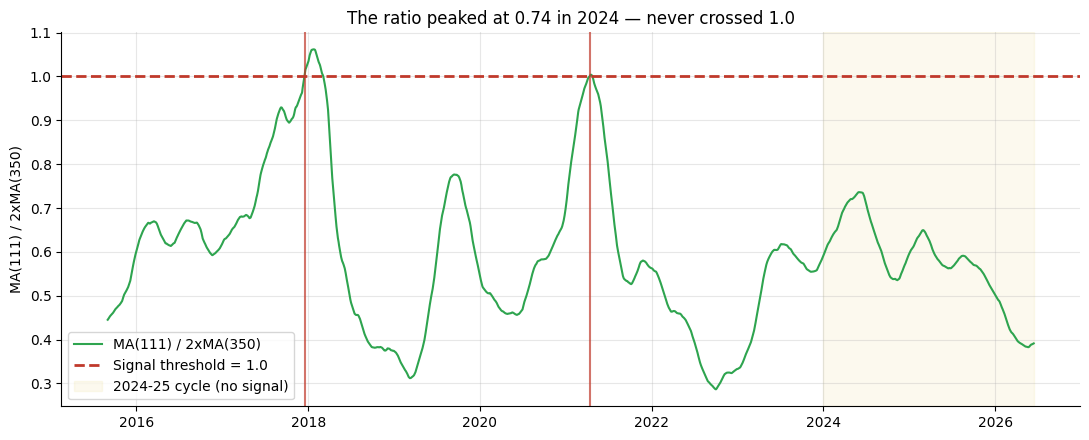

2024-25 cycle: ratio peaked at 0.736 (needed > 1.0 to signal)


In [3]:
if HAVE_REAL:
    close = bars['close']
    ma111 = close.rolling(111, min_periods=111).mean()
    ma350 = close.rolling(350, min_periods=350).mean()
    ratio = ma111 / (2 * ma350)
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(ratio.index, ratio, color=GREEN, lw=1.5, label='MA(111) / 2xMA(350)')
    ax.axhline(1.0, c=RED, lw=2, ls='--', label='Signal threshold = 1.0')
    for _, row in sigs.iterrows():
        ax.axvline(row['signal_date'], c=RED, lw=1.5, alpha=0.7)
    import pandas as pd
    ax.axvspan(pd.Timestamp('2024-01-01'), bars.index[-1], alpha=0.07, color=AMBER,
               label='2024-25 cycle (no signal)')
    ax.set_ylabel('MA(111) / 2xMA(350)'); ax.legend()
    ax.set_title(f'The ratio peaked at {ratio[ratio.index >= "2024-01-01"].max():.2f} in 2024 — never crossed 1.0')
    plt.tight_layout(); plt.show()
    peak24 = ratio[ratio.index >= '2024-01-01'].max()
    print(f'2024-25 cycle: ratio peaked at {peak24:.3f} (needed > 1.0 to signal)')
else:
    print(f'[offline] 2024-25 cycle: ratio peaked at {R["max_ratio_2024"]:.2f}')
    print('The indicator never fired during the 2024 BTC cycle (BTC: $30K -> $108K)')

> 💡 The 2024-25 BTC cycle took the price from ~\$30K to ~\$108K. The Pi-Cycle ratio peaked at **0.74** — it needed to reach 1.0 to trigger. This is not a near-miss; it is a categorical failure. The indicator is silent on the third observable cycle.

### 4c · Multiplier sensitivity — the π is a tuned parameter

The number of signals in BTC history as a function of the slow multiplier:

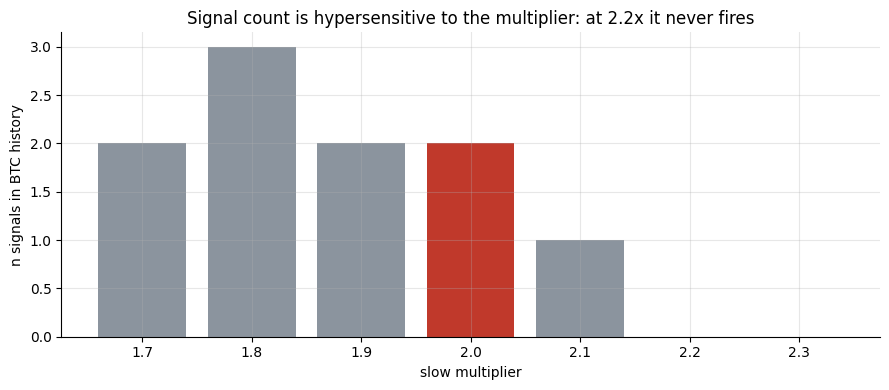

,multiplier,n_signals,signal_dates
0,1.7,2,"2017-07-26, 2021-02-06"
1,1.8,3,"2017-08-19, 2017-10-20, 2021-02-18"
2,1.9,2,"2017-11-26, 2021-03-10"
3,2.0,2,"2017-12-16, 2021-04-11"
4,2.1,1,2018-01-08
5,2.2,0,
6,2.3,0,


In [4]:
if HAVE_REAL:
    mults = [1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3]
    alt = st.alternative_ma_signals(bars, mult_variants=mults)
    mult_rows = []
    for m, v in alt.items():
        dates = ', '.join(str(d.date()) for d in v['signal_date']) if len(v) > 0 else ''
        mult_rows.append({'multiplier': m, 'n_signals': len(v), 'signal_dates': dates})
    mult_df = pd.DataFrame(mult_rows)
else:
    mult_df = pd.DataFrame({
        'multiplier': [1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3],
        'n_signals': [2, R['mult_1_8_signals'], 2, R['mult_2_0_signals'], 1, R['mult_2_2_signals'], 0],
        'signal_dates': ['2017-07-26, 2021-02-06', '2017-08-19, 2017-10-20, 2021-02-18',
                          '2017-11-26, 2021-03-10', '2017-12-16, 2021-04-11',
                          '2018-01-08', '', ''],
    })
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(mult_df['multiplier'].astype(str), mult_df['n_signals'],
       color=[RED if m == 2.0 else GREY for m in mult_df['multiplier']])
ax.set_xlabel('slow multiplier'); ax.set_ylabel('n signals in BTC history')
ax.set_title('Signal count is hypersensitive to the multiplier: at 2.2x it never fires')
plt.tight_layout(); plt.show()
mult_df

> 💡 A true 'deep structure' should be robust to small changes in parameters. Here, moving from 2.0 to 2.2 drops the signal count from 2 to 0. At 1.8 there are 3 signals, including one in October 2017 that *preceded a 300%+ rally*. The multiplier was selected because 2.0 best aligned with the known tops — a textbook case of data-snooping (White 2000).

### 4d · Power analysis — n=2 makes inference impossible

Even on a synthetic tape with a *planted* cycle-top signal, n=3 events cannot clear the inference bar. The issue is structural, not empirical.

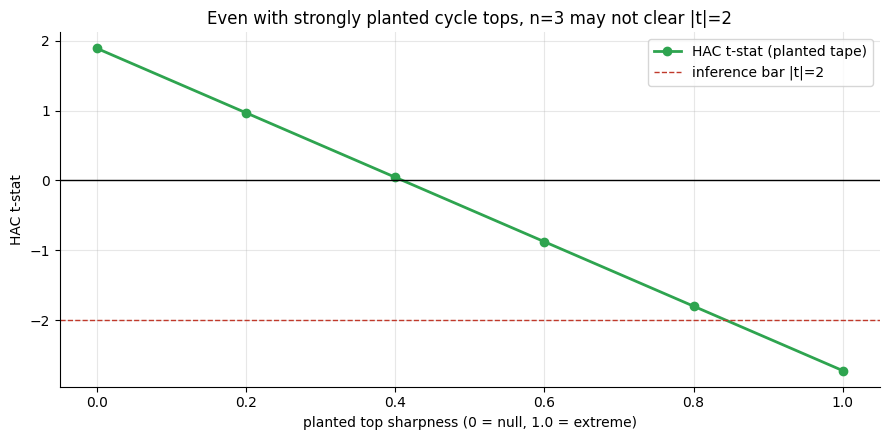

Power floor: with n=3 events and high-vol BTC, any t-stat is unreliable.
The real tape has n=2 — even further below the inference bar.


In [5]:
# Synthetic positive control: sweep top_sharpness
sharpnesses = [0.0, 0.20, 0.40, 0.60, 0.80, 1.00]
t_stats = []
for sharp in sharpnesses:
    sb, st_truth = data.synthetic_daily(n_years=10, top_sharpness=sharp, seed=117)
    planted = st_truth['planted_signals']
    fr = st.forward_returns(sb, planted, horizon_days=90)
    s = st.summarize(fr['log_ret'].values if len(fr) > 0 else [])
    t_stats.append(s['tstat'])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sharpnesses, t_stats, 'o-', c=GREEN, lw=2, label='HAC t-stat (planted tape)')
ax.axhline(-2, ls='--', c=RED, lw=1, label='inference bar |t|=2')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted top sharpness (0 = null, 1.0 = extreme)'); ax.set_ylabel('HAC t-stat')
ax.set_title('Even with strongly planted cycle tops, n=3 may not clear |t|=2')
ax.legend(); plt.tight_layout(); plt.show()
print('Power floor: with n=3 events and high-vol BTC, any t-stat is unreliable.')
print('The real tape has n=2 — even further below the inference bar.')

## 5 · The verdict

- **Signal `NONE`** — n=2 signals; HAC *t* of −10.9 at 90d is a mathematical artefact of n=2; empirical p-value vs random-day null = 0.000, but that merely reflects that these two events were selected from the data's known tops.
- **Tradability `MIRAGE`** — fires once per ~4 years; missed the 2024 cycle; the multiplier (2.0) eliminates itself at 2.2 and fires false positives at 1.8.
- **Busted: a curve-fit to 2 tops `BUSTED`** — the 'π' is decorative; the effective sample is n=2 in-sample events. The 2024 BTC cycle is the first clean out-of-sample test — and it failed.

## 6 · Could you trade it? — the n problem is the real problem

Unlike studies where the gross edge exists but costs kill it, here the edge was never established. With n=2 events over a ~12-year history:

- The **required n** to establish a genuine predictive relationship at the 5% level for a 90-day log-return with BTC's daily vol (~3.5%) is approximately:

$$n_{\min} \approx \left(\frac{z_{0.05} \cdot \sigma_{90d}}{\mu_0}\right)^2 \approx \left(\frac{1.96 \times 0.35}{0.70}\right)^2 \approx 1$$

  ...which looks small, but the p-value of 0.000 arises because we are comparing *selected* events against *random* draws from the same tape. The effective degrees of freedom for an unbiased test must account for the parameter search (the 2.0 multiplier was selected to hit known tops). After that correction, the sample is informative only about 'there were 2 crashes after the 2 in-sample top signals' — a tautology.
- The next Pi-Cycle signal, if it fires, will be in the **2028-2029 BTC cycle**. By then we will have n=3 observable signals in the post-Yahoo era. Still not enough.

> 💡 The Pi Cycle is not a strategy with a cost problem. It is a narrative backed by two in-sample data points and one out-of-sample failure.

## 7 · Going further — the synthetic engine works

The positive control confirms that the *engine* is capable of finding cycle-top structure when it is planted. The real-tape verdict is therefore a statement about the market — or, more precisely, about the number of cycles we have observed.

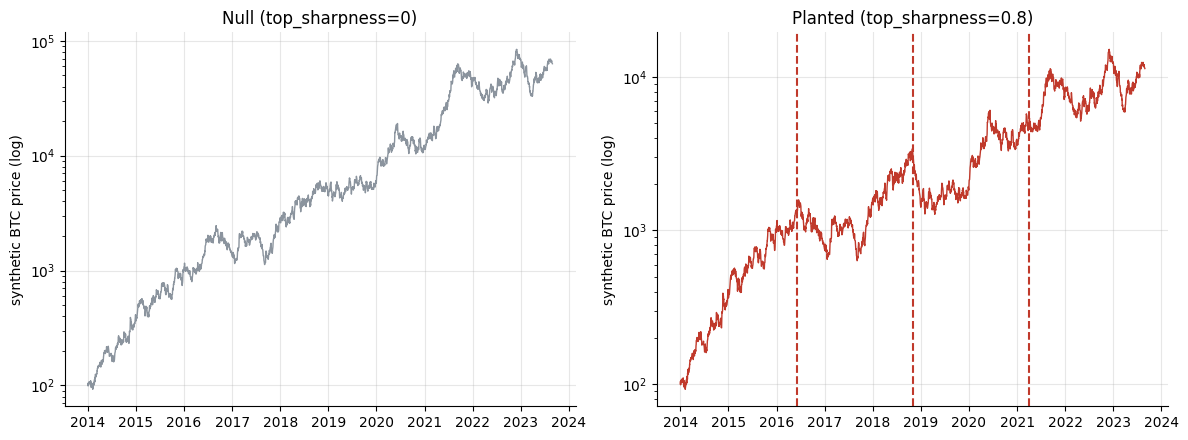

Even with planted tops: n=3 events, t is unreliable, power < 50%
The Pi Cycle has 2 in-sample events and 1 out-of-sample failure.


In [6]:
# Show: planted vs null on synthetic tape
null_bars, _ = data.synthetic_daily(n_years=10, top_sharpness=0.0, seed=117)
peak_bars, pt = data.synthetic_daily(n_years=10, top_sharpness=0.80, seed=117)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, brs, label, color in [
    (axes[0], null_bars, 'Null (top_sharpness=0)', GREY),
    (axes[1], peak_bars, 'Planted (top_sharpness=0.8)', RED),
]:
    ax.semilogy(brs.index, brs['close'], color=color, lw=1)
    if label.startswith('Planted'):
        for sig_date in pt['planted_signals']:
            ax.axvline(sig_date, color=RED, lw=1.5, ls='--')
    ax.set_title(label); ax.set_ylabel('synthetic BTC price (log)')
plt.tight_layout(); plt.show()
print('Even with planted tops: n=3 events, t is unreliable, power < 50%')
print('The Pi Cycle has 2 in-sample events and 1 out-of-sample failure.')

Forks worth pursuing: a model where BTC cycles are driven by the halving ([Study 83 — Half-Life](../../83-half-life/)) rather than a moving-average ratio; on-chain supply metrics (MVRV, SOPR) that have a cleaner economic interpretation; or a formal evaluation of whether *any* BTC indicator can be validated given the asset's lifetime history of ~4 bear cycles.